Creating GAN model...
Training GAN...
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 51s 101ms/step - d_loss: 0.1612 - g_loss: 4.8673
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 46s 98ms/step - d_loss: 0.0202 - g_loss: 5.4162
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 87ms/step - d_loss: 0.0355 - g_loss: 6.9826
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 88ms/step - d_loss: 0.0215 - g_loss: 8.3183
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 91ms/step - d_loss: 4.0325e-04 - g_loss: 8.6748

Generating new digits...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


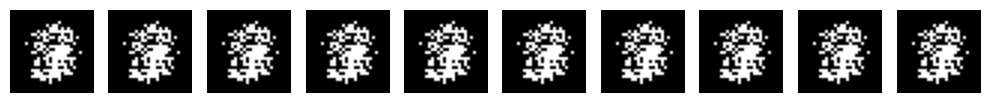

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense, Reshape, Flatten, LeakyReLU
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load and preprocess MNIST data
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), 28, 28, 1))

# Network parameters
latent_dim = 150
img_shape = (28, 28, 1)
batch_size = 128
epochs = 5  # Reduced epochs for faster training

def build_generator():
    noise_input = Input(shape=(latent_dim,))

    x = Dense(256)(noise_input)
    x = LeakyReLU(alpha=0.2)(x)
    x = Dense(512)(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = Dense(1024)(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = Dense(512)(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = Dense(np.prod(img_shape), activation='sigmoid')(x)
    x = Reshape(img_shape)(x)

    generator = Model(noise_input, x, name='generator')
    return generator

def build_discriminator():
    img_input = Input(shape=img_shape)

    x = Flatten()(img_input)
    x = Dense(512)(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = Dense(256)(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = Dense(1, activation='sigmoid')(x)

    discriminator = Model(img_input, x, name='discriminator')
    return discriminator

class GAN(tf.keras.Model):
    def __init__(self, discriminator, generator):
        super().__init__()
        self.discriminator = discriminator
        self.generator = generator

        # Track losses
        self.d_loss_tracker = tf.keras.metrics.Mean(name='d_loss')
        self.g_loss_tracker = tf.keras.metrics.Mean(name='g_loss')

    @property
    def metrics(self):
        return [self.d_loss_tracker, self.g_loss_tracker]

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super().compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn

    def train_step(self, real_images):
        batch_size = tf.shape(real_images)[0]

        # Train discriminator
        noise = tf.random.normal([batch_size, latent_dim])
        generated_images = self.generator(noise)

        with tf.GradientTape() as tape:
            # Real images
            real_output = self.discriminator(real_images)
            # Fake images
            fake_output = self.discriminator(generated_images)

            # Calculate discriminator loss
            d_loss_real = self.loss_fn(tf.ones_like(real_output), real_output)
            d_loss_fake = self.loss_fn(tf.zeros_like(fake_output), fake_output)
            d_loss = (d_loss_real + d_loss_fake) / 2

        # Update discriminator
        d_grads = tape.gradient(d_loss, self.discriminator.trainable_variables)
        self.d_optimizer.apply_gradients(zip(d_grads, self.discriminator.trainable_variables))

        # Train generator
        noise = tf.random.normal([batch_size, latent_dim])

        with tf.GradientTape() as tape:
            # Generate fake images
            generated_images = self.generator(noise)
            # Get discriminator output
            fake_output = self.discriminator(generated_images)
            # Calculate generator loss
            g_loss = self.loss_fn(tf.ones_like(fake_output), fake_output)

        # Update generator
        g_grads = tape.gradient(g_loss, self.generator.trainable_variables)
        self.g_optimizer.apply_gradients(zip(g_grads, self.generator.trainable_variables))

        # Update metrics
        self.d_loss_tracker.update_state(d_loss)
        self.g_loss_tracker.update_state(g_loss)

        return {
            "d_loss": self.d_loss_tracker.result(),
            "g_loss": self.g_loss_tracker.result()
        }

# Build and compile the GAN
print("Creating GAN model...")
discriminator = build_discriminator()
generator = build_generator()

gan = GAN(discriminator, generator)
gan.compile(
    d_optimizer=Adam(learning_rate=0.0002, beta_1=0.5),
    g_optimizer=Adam(learning_rate=0.0002, beta_1=0.5),
    loss_fn=tf.keras.losses.BinaryCrossentropy()
)

# Train the GAN
print("Training GAN...")
gan.fit(x_train, epochs=epochs, batch_size=batch_size)

def generate_digits(generator, n=10):
    """Generate n new digits using the generator"""
    noise = tf.random.normal([n, latent_dim])
    generated_images = generator.predict(noise)
    return generated_images

# Generate and visualize new digits
print("\nGenerating new digits...")
new_digits = generate_digits(generator, 10)

plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(new_digits[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()